In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
####1.Data Exploration:
## a.Load the dataset and EDA :
df=pd.read_csv('diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.shape

(768, 9)

In [5]:
df.size

6912

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

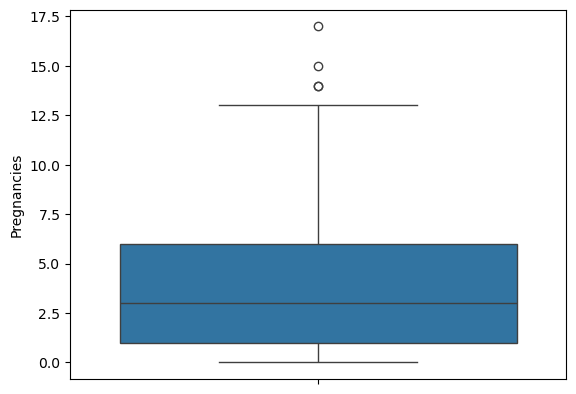

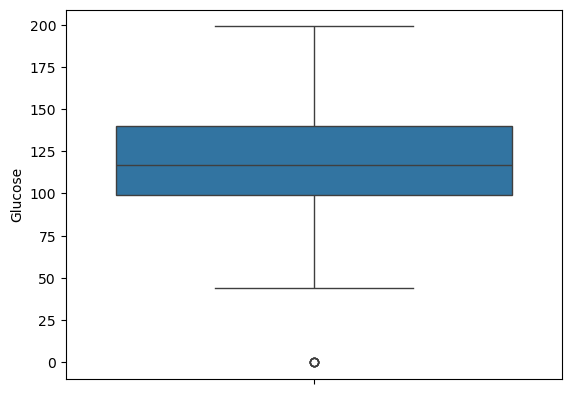

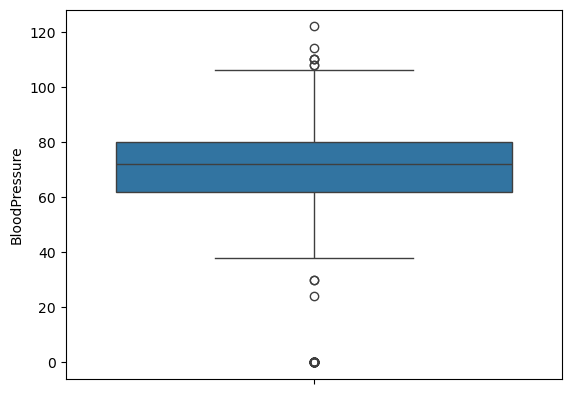

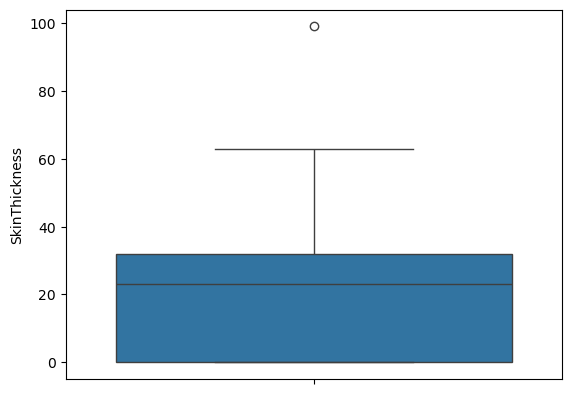

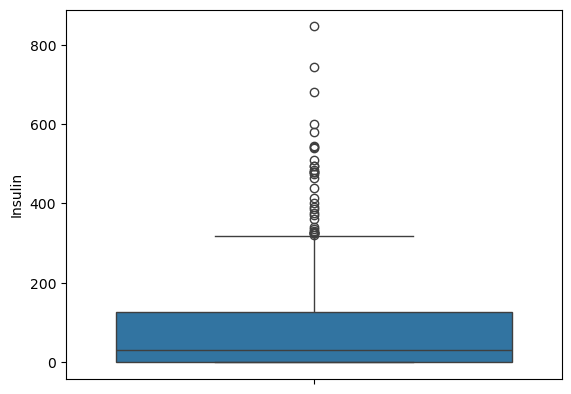

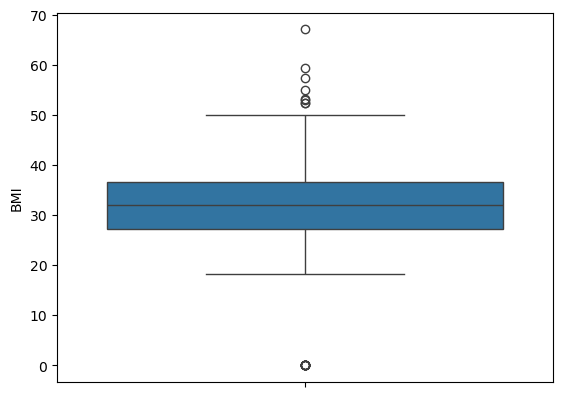

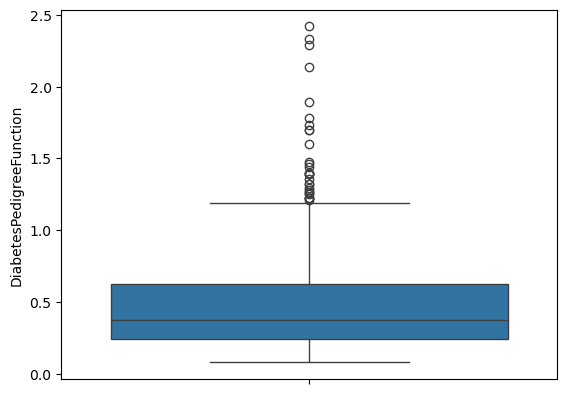

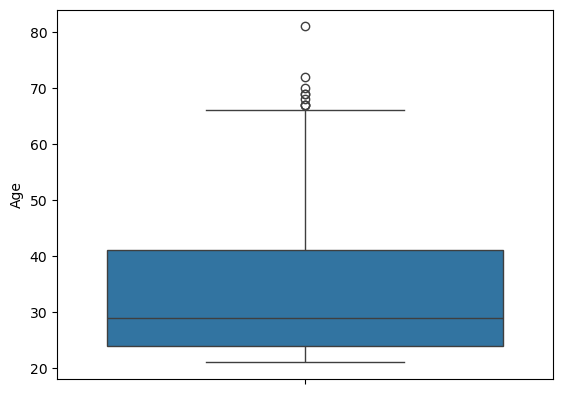

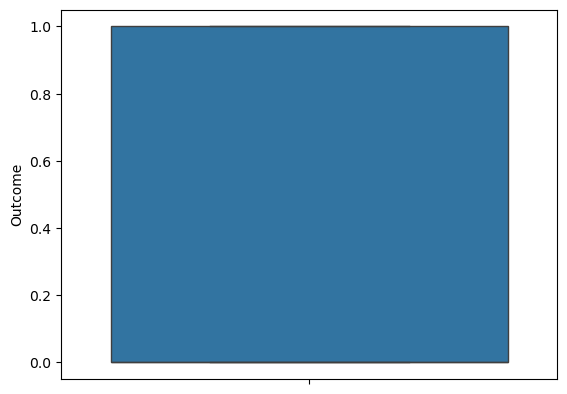

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [10]:
#Outlier capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

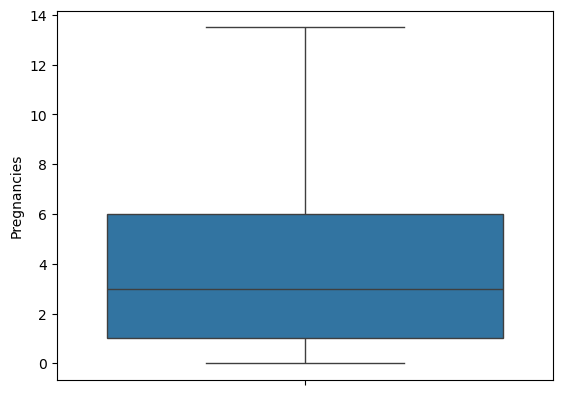

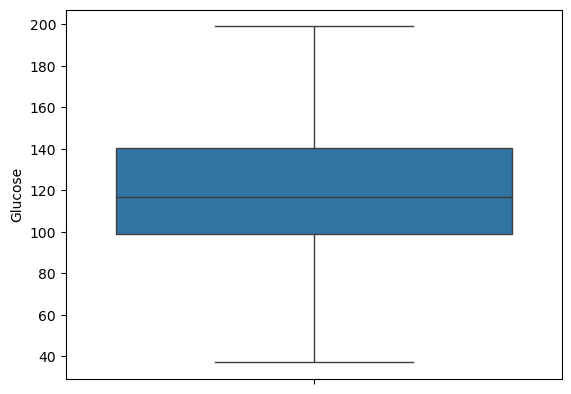

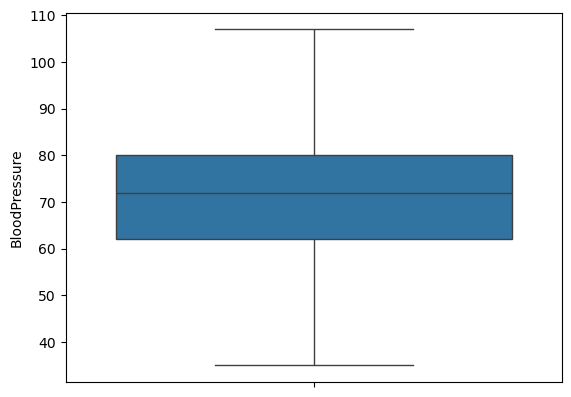

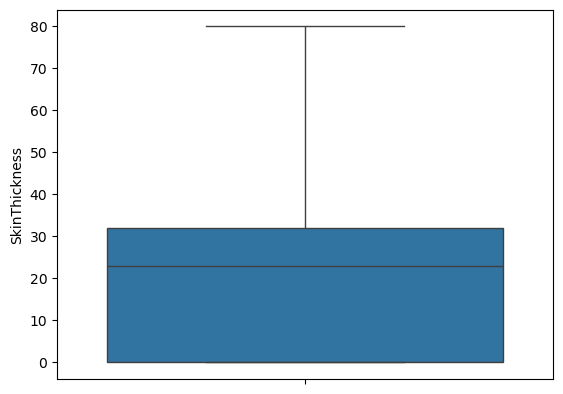

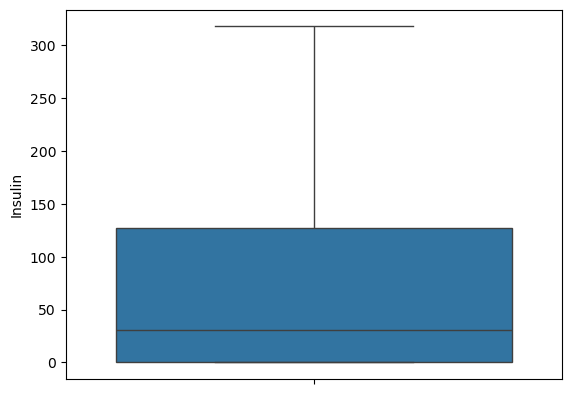

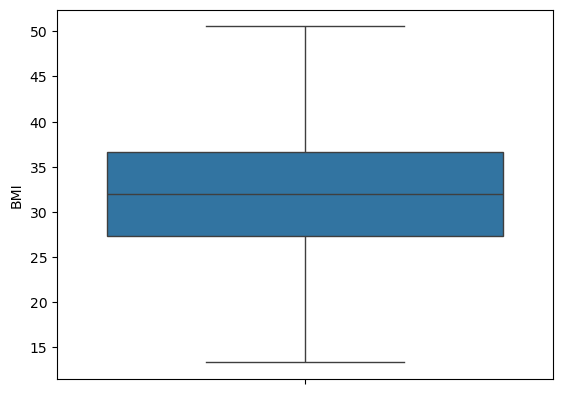

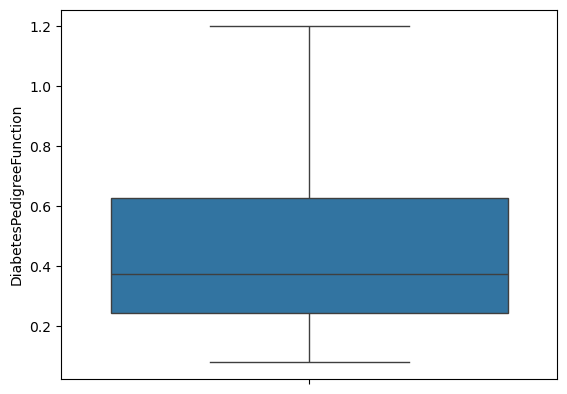

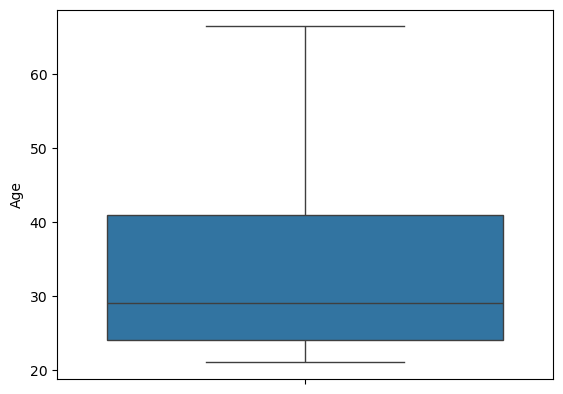

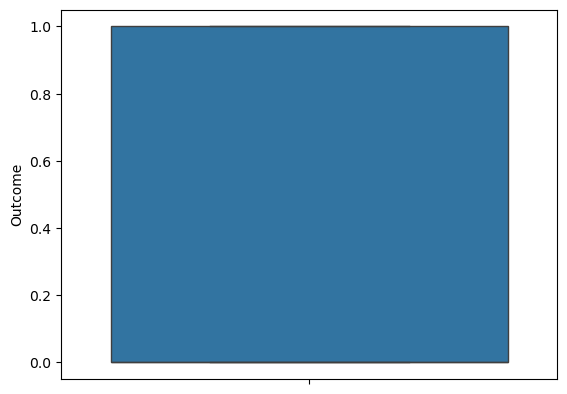

In [11]:
#Checking Outliers again after capping
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [12]:
###b.Features,Datatypes,Summary Statistics:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [13]:
df.dtypes

Pregnancies                 float64
Glucose                     float64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


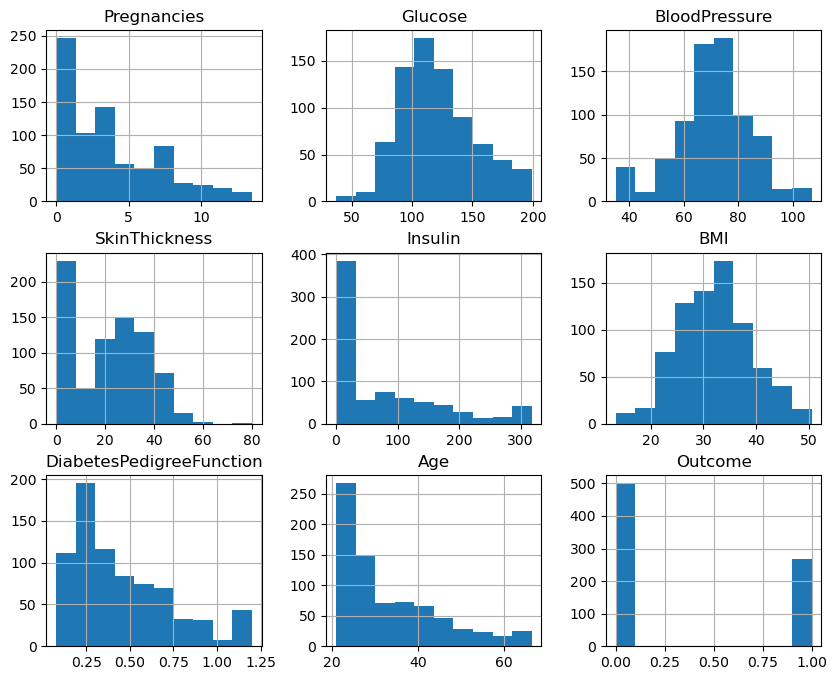

In [15]:
###c.Histograms and Boxplots:
df.hist(figsize=(10,8))
plt.show()

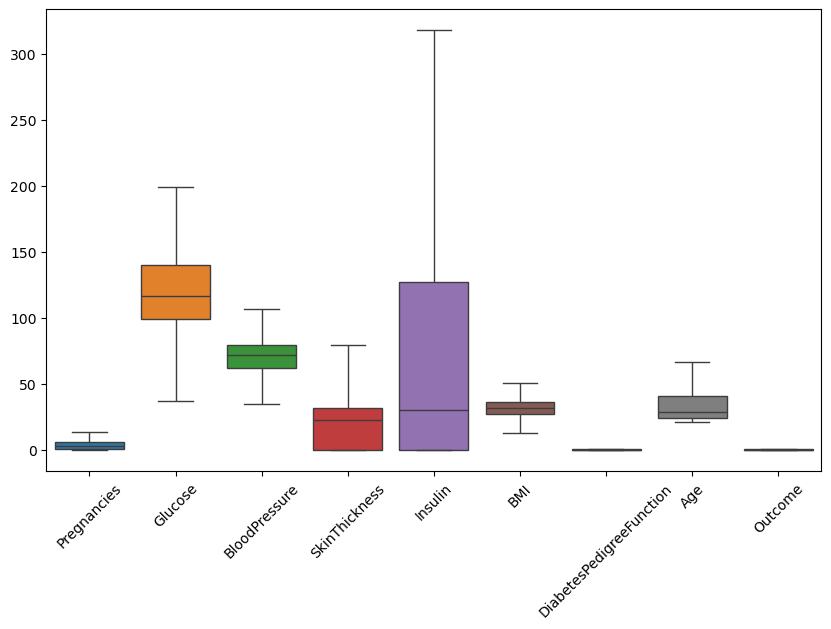

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

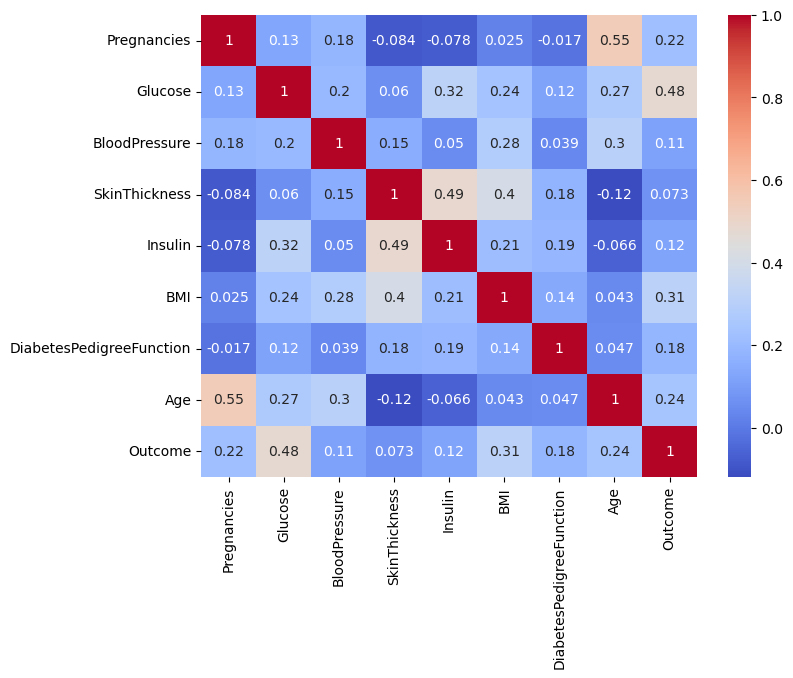

In [17]:
######Correlation Heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

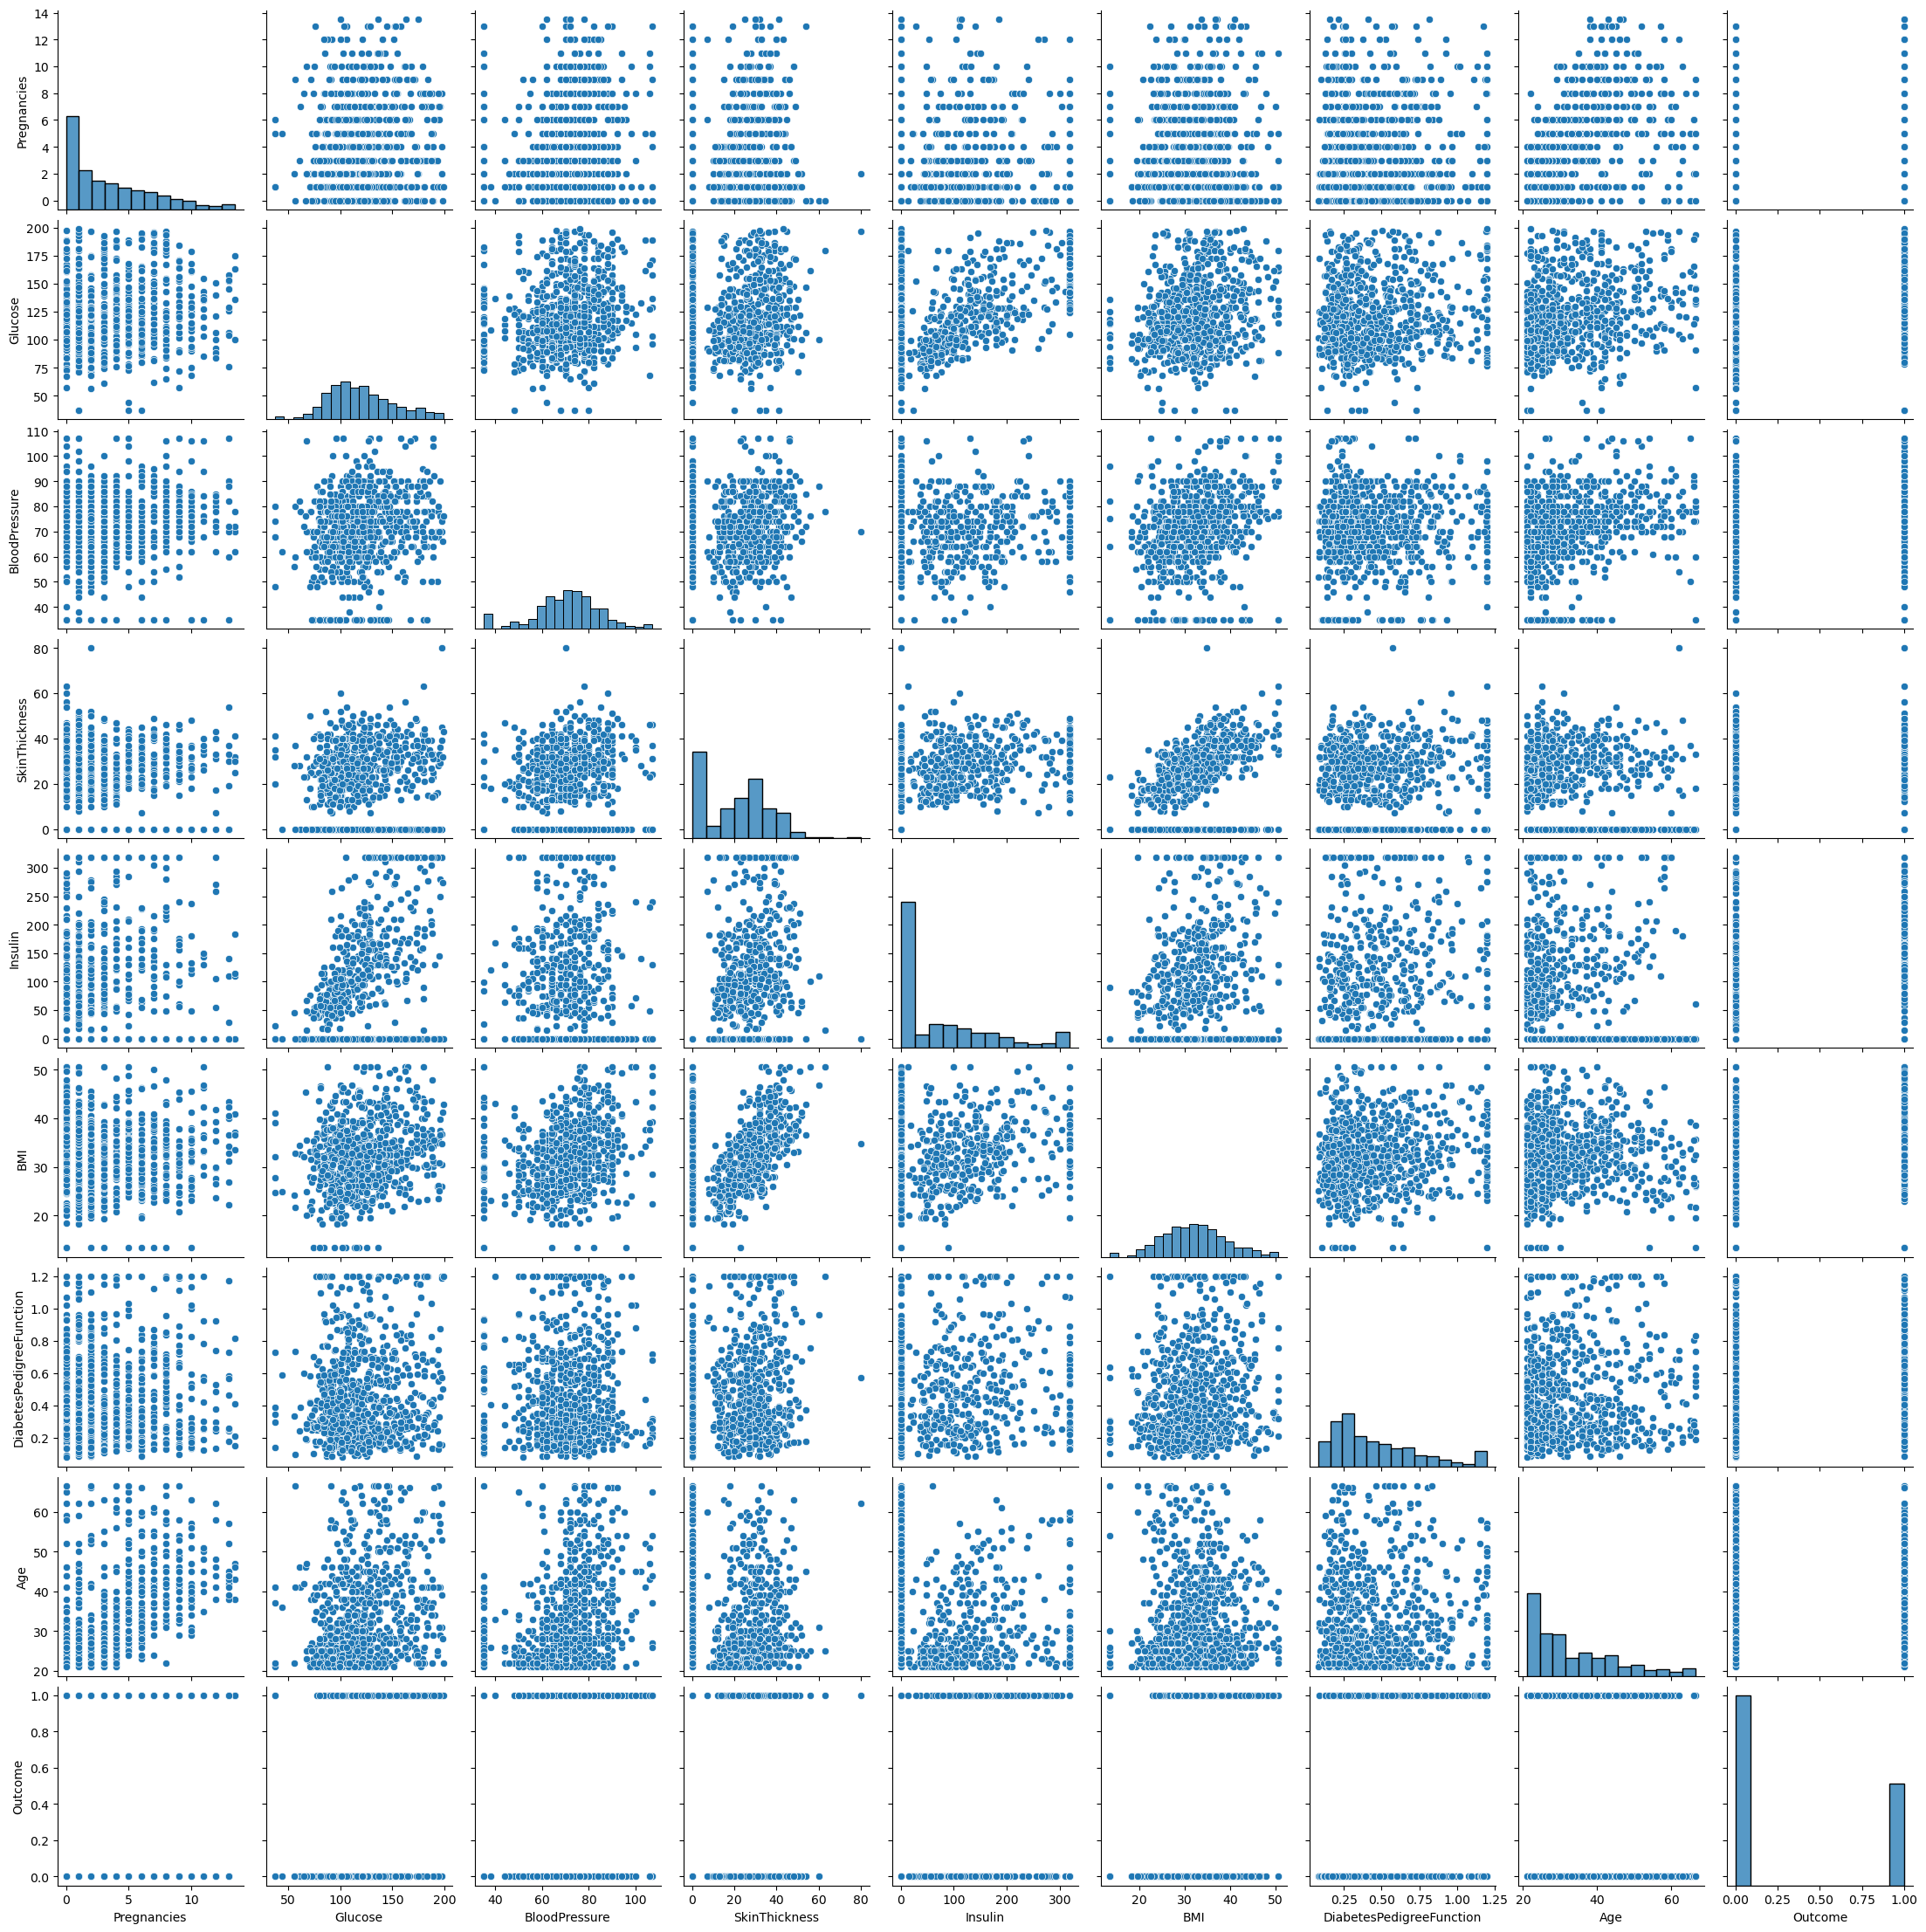

In [18]:
### Pair Plot
sns.pairplot(df)
plt.show()

In [19]:
X = df.drop("Outcome", axis=1)

In [20]:
#####2.DATA PREPROCESSING:
##### a.HAndle Missing Values:
X = X.replace(0, np.nan)
X = X.fillna(X.mean())

In [21]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72,35,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66,29,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64,0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66,23,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40,35,168.0,43.1,1.200,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76,48,180.0,32.9,0.171,63.0,0
764,2.0,122.0,70,27,0.0,36.8,0.340,27.0,0
765,5.0,121.0,72,23,112.0,26.2,0.245,30.0,0
766,1.0,126.0,60,0,0.0,30.1,0.349,47.0,1


In [22]:
##### b.Encode Categorical Variables:
categorical_cols = df.select_dtypes(include=['object']).columns

In [23]:
categorical_cols

Index([], dtype='object')

## Categorical Variable Encoding:

The dataset contains only numerical features, so categorical encoding was not required.

In [24]:
######3.Model Building:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [25]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [26]:
###Splitting data into training and testing:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=50)

In [27]:
####Feature Scaling :
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
####Train Logistic Regression Model:
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
####Make Predictions:
y_pred = model.predict(x_test)

In [30]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0])

In [31]:
######4.Model Evaluation:
####Accuracy:
from sklearn.metrics import accuracy_score 
accuracy = accuracy_score(y_test, y_pred)

In [32]:
accuracy

0.7467532467532467

In [33]:
#####Precision,Recall,f1-score:
from sklearn.metrics import classification_report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       101
           1       0.68      0.49      0.57        53

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154



In [34]:
####ROC and AUC Score:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
auc

0.7780683728750233

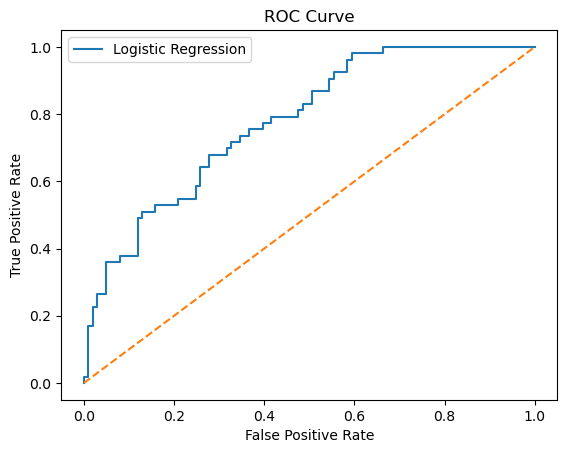

In [35]:
###ROC CURVE:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [36]:
##5.Interpretation:
####a.Model Coefficients:
coefficients = pd.DataFrame({ 'Feature': X.columns, 'Coefficient': model.coef_[0] })

In [37]:
coefficients

,Feature,Coefficient
0,Pregnancies,0.407869
1,Glucose,1.160446
2,BloodPressure,-0.313659
3,SkinThickness,-0.099969
4,Insulin,-0.111814
5,BMI,0.827072
6,DiabetesPedigreeFunction,0.353730
7,Age,0.195974


###### Interpretation of Logistic Regression Coefficients:

The logistic regression coefficients indicate the direction and strength of the relationship between each feature and the predicted outcome. Positive coefficients indicate that an increase in the feature is associated with higher predicted odds of diabetes, while negative coefficients indicate lower predicted odds, holding other features constant. Since the features were standardized, the coefficient magnitudes can be compared more meaningfully. Glucose has a strong influence on the model's predictions, while BMI, Age, and DiabetesPedigreeFunction also contribute to predicting diabetes.

###### b.Significance of Features in Predicting the Target Variable:

The importance of individual features is interpreted from their model coefficients and should not be confused with statistical significance. Features with larger absolute coefficient values have a greater influence on the model's predictions, while the sign of the coefficient indicates the direction of the association.

In [38]:
#####6.Deployment:
import pickle

# Save trained model
pickle.dump(model, open('diabetes_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))


###### Local Streamlit Deployment: 
The logistic regression model was successfully deployed locally using Streamlit. The trained model  app.py,(diabetes_model.pkl) and scaler (scaler.pkl) were loaded into the application. User input fields were created for medical parameters such as glucose, blood pressure, BMI, insulin, and age. After clicking the Predict button, the application displays whether the person is likely to have diabetes or not. The app was executed locally using the command streamlit run app.py and accessed through http://localhost:8501.

## Interview Questions:

### 1. What is the difference between precision and recall?

* **Precision:** Out of all predicted positive cases, how many are actually positive.
* **Recall:** Out of all actual positive cases, how many are correctly predicted.

### 2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique that splits the dataset into multiple parts, trains the model on some parts, and tests it on the remaining part repeatedly. It is important because it provides a more reliable estimate of model performance and helps reduce overfitting.
